# Image classification 

For classification purpose, the output layer needs to be a FC layer with its output the class number. 

ViT needs to append a FC layer (head) because its strucute was originally designed for NLP; for other CNN based model, can modify the last layer in-place.

Fine-tuning can:
1. Update the parameters of the whole model
2. Only update the last layer (or certain layers). Can make these parts require_grad=False.

Notes:
1. By default, pretrained PyTorch models (huggingface) are built considering input data (N,C,H,W) as the first layer or embedding layer. Model itself is built with weights only taking a single data (C,H, W) because no need to duplicated the parameters. For example, the ViT model used in this notebook handles batches in the model embedding layer.
2. PyTorch dataloader will prepare data in correct batch (N,C,H,W). Then you can write outputs=model(batch_data). It will feed each data into the "actual" model, calculate the score per data,and ouput the results in batch.
3. Then you can use criterion to calculate a single loss score per minibatch, and update the weights per minibatch (instead of the whole dataset).
4. PyTorch-Lightning handles batch inside the trainer() class.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import os

# Training
## Parameters

In [2]:
# Models to choose from [resnet, alexnet, vgg, squeezenet, densenet, inception]
model_name = 'vit_p32' #"vit_p32" #"resnet" #"squeezenet"

# Number of classes in the dataset
num_classes = 2

# Batch size during training
batch_size = 16

# Number of epochs to train for 
num_epochs = 1000

# Flag for feature extracting. When False, we finetune the whole model, when True we only update the reshaped layer params
feature_extract = True

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(device)

# output_dir
round_info= 'round2_ft'
#round_info= 'round2_ft'
out_dir = '/lovelace/xiaoya/scientific_txt2image-main/classifier_checkpoints/'+round_info+'/'+model_name+'/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

cuda:0


## Dataset

round2_ft /lovelace/xiaoya/GenAI_dataset/zz_xy_rings_5k_2_1000real_exp_1000fake
88 38


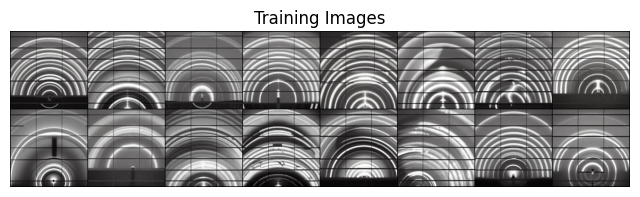

In [3]:
from model_utils import myDataloader

#dataroot = "./discriminator_data/data"
#dataroot = "/lovelace/zhuowen/diffusers/als/40k_generated/als_2400_labeled"
#dataroot = "/lovelace/xiaoya/GenAI_dataset/generated_and_experimental_data"
if round_info =='round1':
    dataroot = "/lovelace/xiaoya/GenAI_dataset/generated_and_experimental_data"
else:
    dataroot = "/lovelace/xiaoya/GenAI_dataset/zz_xy_rings_5k_2_1000real_exp_1000fake"

print(round_info,dataroot)

if model_name =='inception':
    input_size = 299
else:
    input_size = 224
transform=transforms.Compose([transforms.Resize(input_size),
                              transforms.CenterCrop(input_size),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                             ])
dataloaders =  myDataloader(root=dataroot, 
                            batch_size=batch_size, 
                            transform=transform,
                            num_workers = 2,
                            split=[0.7, 0.3],
                            from_subfolders=True)

train_dataloader, val_dataloader = dataloaders.dataloader()
print(len(train_dataloader), len(val_dataloader))
    
dataloaders.plot_dataloader(train_dataloader, device)

# Create training and validation dataloaders
dataloaders_dict = {'train': train_dataloader, 'validation':val_dataloader}


## Training example

In [4]:
from model_utils import myModels

# Initialize the model for this run
model_ft, input_size = myModels.initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)

if round_info == 'round2_ft':
    round1_dir = '/lovelace/xiaoya/scientific_txt2image-main/classifier_checkpoints/round1/'+model_name+'/'
    model_ft = torch.load(round1_dir+model_name+'_'+str(num_epochs)+'_epochs_classifier.pth')
    print("use ckpt from round 1:",round1_dir)
# Print the model we just instantiated
#print(model_ft)

# Gather the parameters to be optimized/updated in this run. If we are
#  finetuning we will be updating all parameters. However, if we are 
#  doing feature extract method, we will only update the parameters
#  that we have just initialized, i.e. the parameters with requires_grad is True.
params_to_update = model_ft.parameters()
print("Params to learn:")
if feature_extract:
    params_to_update = []
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t",name)
else:
    for name,param in model_ft.named_parameters():
        if param.requires_grad == True:
            print("\t",name)

Some weights of the model checkpoint at google/vit-base-patch32-224-in21k were not used when initializing ViTModel: ['pooler.dense.bias', 'pooler.dense.weight']
- This IS expected if you are initializing ViTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ViTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


use ckpt from round 1: /lovelace/xiaoya/scientific_txt2image-main/classifier_checkpoints/round1/vit_p32/
Params to learn:
	 classifier.weight
	 classifier.bias


In [ ]:
from pipeline_utils import Trainer

# define optimizer and loss
optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

# Train and evaluate
trainer = Trainer(model_ft, 
                  dataloaders_dict, 
                  criterion, 
                  optimizer_ft,
                  device=device, 
                  num_epochs=num_epochs, 
                  is_inception=(model_name=="inception"), 
                  verbose=True
                  )
model_ft, hist = trainer.train()

Epoch 0/999
----------


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:04<00:00, 17.91it/s]


train loss: 0.3659 acc: 0.8521


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:01<00:00, 24.81it/s]


validation loss: 0.3709 acc: 0.8517
Epoch 1/999
----------


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:02<00:00, 32.13it/s]


train loss: 0.1485 acc: 0.9436


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:01<00:00, 28.34it/s]


validation loss: 0.2437 acc: 0.8933
Epoch 873/999
----------


 41%|██████████████████████████████████████████████████▋                                                                         | 36/88 [00:01<00:01, 36.54it/s]

In [ ]:
trainer.plot_history(10, save_fig=True, out_name=out_dir+'history_'+model_name+'_'+str(num_epochs)+'epochs_classifier.png')
trainer.save_results(out_dir, model_name=model_name+'_'+str(num_epochs)+'_epochs_classifier')

# Evaluation example (vit_16x16)

In [5]:
import torchvision
from pipeline_utils import Evaluation

dataset = torchvision.datasets.ImageFolder(root="/lovelace/xiaoya/GenAI_dataset/xc_ring_1k_0_100_2nd_corrected", 
                                                   transform=transform)
eval_dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [6]:
vit_p16 = torch.load(out_dir+model_name+'_'+str(num_epochs)+'_epochs_classifier.pth')
vit_p16_eval = Evaluation(vit_p16, eval_dataloader, threshold=0.56, device=device)
print(out_dir+model_name+'_'+str(num_epochs)+'_epochs_classifier.pth')
vit_p16_eval.evaluate()

/lovelace/xiaoya/scientific_txt2image-main/classifier_checkpoints/round2_ft/vit_p32/vit_p32_1000_epochs_classifier.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:02<00:00,  5.10it/s]

avg acc: 0.8199999928474426, prec: 0.8453608155250549


## Inferencing example (vit_16x16)

In [9]:
# from model_utils import myDataset
# from pipeline_utils import Inference
# import glob

# test_data_path = '/lovelace/xiaoya/GenAI_dataset/xc_ring_1k_0_100_2nd_corrected'
# filepaths = glob.glob(test_data_path+'/*')

# test_dataset = myDataset(root=test_data_path, 
#                          transform=transform,
#                          return_filepath=True)


# test_dataloader = torch.utils.data.DataLoader(test_dataset,
#                                               batch_size=batch_size,
#                                               shuffle=False,
#                                               num_workers=0,
#                                               drop_last=False,
#                                               prefetch_factor=None)

In [10]:
# #inference_data_path = '/lovelace/xiaoya/GenAI_dataset/xc_ring_1k_0_100_2nd_corrected'

# # load trained model 
# vit_p16 = torch.load(out_dir+model_name+'_'+str(num_epochs)+'_epochs_classifier.pth')
# vit_p16_infer = Inference(vit_p16, test_dataloader, threshold=0.56, device=device, filepaths=filepaths)
# vit_p16_infer.next_batch()

## Ensemble classification and evaluation 